# Principal Component Analysis (PCA) — Dimensionality Reduction on Pixel Data

**Objective:** find how many of 64 pixel-features can be dropped before a classifier's accuracy actually suffers.
**Method:** PCA (variance-based dimensionality reduction), measured against a Logistic Regression classifier's accuracy and training time.

**Data:** `sklearn.datasets.load_digits` — 1,797 handwritten-digit images (0-9), 8x8 pixels flattened to 64 features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

dataset = load_digits()
print(f"Samples: {dataset.data.shape[0]}, Features (pixels): {dataset.data.shape[1]}")

Samples: 1797, Features (pixels): 64


## STEP 01 - Inspect the Raw Data

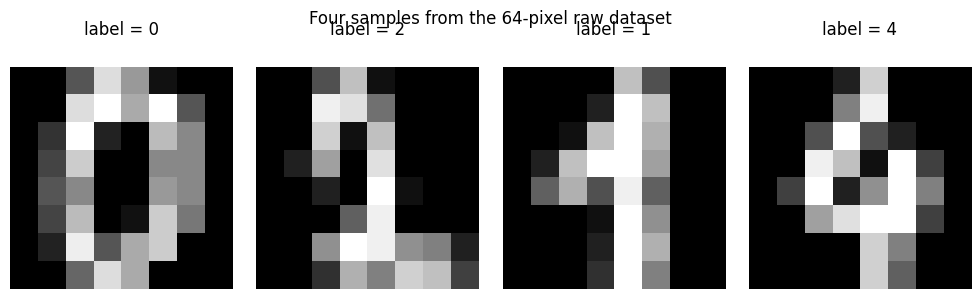

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for ax, idx in zip(axes, [0, 12, 42, 100]):
    ax.matshow(dataset.data[idx].reshape(8, 8), cmap='gray')
    ax.set_title(f"label = {dataset.target[idx]}")
    ax.axis('off')
plt.suptitle("Four samples from the 64-pixel raw dataset")
plt.tight_layout()
plt.show()

In [3]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
X = df
y = dataset.target
df.describe().loc[['mean', 'std', 'min', 'max']]

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,3.725097,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,4.919406,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,16.000000,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000


## STEP 02 - Baseline Classifier on All 64 Pixels

Features are scaled first (PCA requires this) and a baseline is trained on the full feature set before reducing anything.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ALPHA = 0.2
SEED = 30

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=ALPHA, random_state=SEED)

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)
baseline_accuracy = baseline_model.score(X_test, y_test)
print(f"Baseline accuracy (all 64 pixels): {baseline_accuracy:.4f}")

Baseline accuracy (all 64 pixels): 0.9722


## STEP 03 - Apply PCA at 95% Variance Retained

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions : {X_scaled.shape[1]}")
print(f"Reduced dimensions  : {pca.n_components_}  (95% variance retained)")
print(f"Compression         : {1 - pca.n_components_ / X_scaled.shape[1]:.1%} fewer features")

Original dimensions : 64
Reduced dimensions  : 40  (95% variance retained)
Compression         : 37.5% fewer features


In [6]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=ALPHA, random_state=SEED)

pca_model = LogisticRegression(max_iter=1000)
pca_model.fit(X_train_pca, y_train_pca)
pca_accuracy = pca_model.score(X_test_pca, y_test_pca)

print(f"Accuracy with {pca.n_components_} components : {pca_accuracy:.4f}")
print(f"Accuracy with all 64 pixels          : {baseline_accuracy:.4f}")
print(f"Accuracy change                      : {pca_accuracy - baseline_accuracy:+.4f}")

Accuracy with 40 components : 0.9639
Accuracy with all 64 pixels          : 0.9722
Accuracy change                      : -0.0083


## STEP 04 - Scree Plot

Variance explained per component and the cumulative total, marking where 95% is reached.

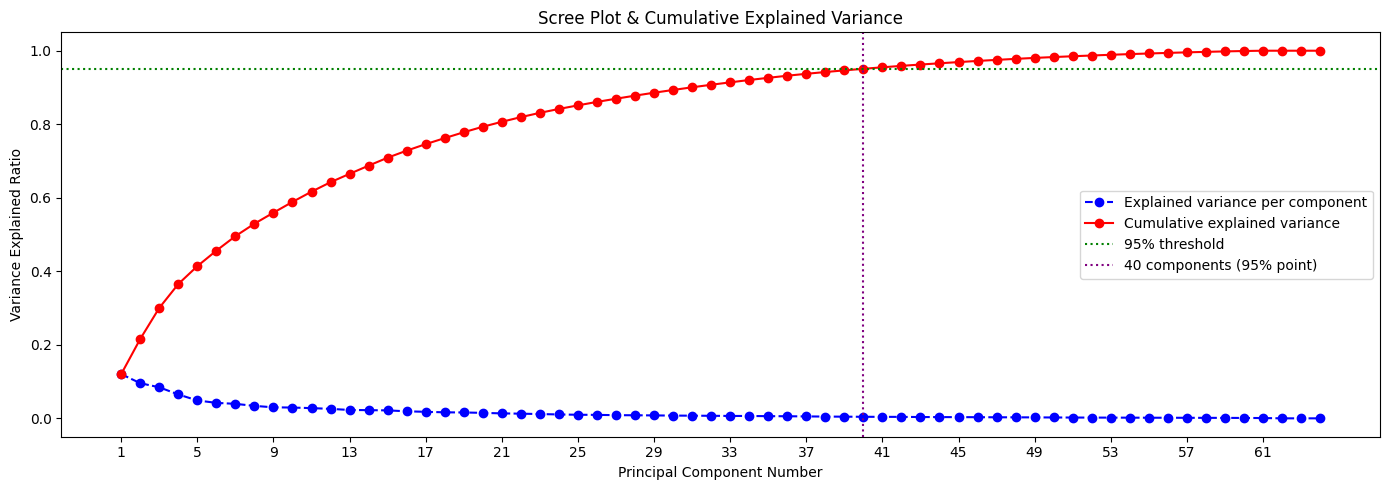

In [7]:
n_components_full = X.shape[1]
pca_full = PCA(n_components=n_components_full)
pca_full.fit(X_scaled)

per_component = pca_full.explained_variance_ratio_
cumulative = np.cumsum(per_component)
components_axis = range(1, len(per_component) + 1)

plt.figure(figsize=(14, 5))
plt.plot(components_axis, per_component, marker='o', linestyle='--', color='b', label='Explained variance per component')
plt.plot(components_axis, cumulative, marker='o', linestyle='-', color='r', label='Cumulative explained variance')
plt.axhline(0.95, color='green', linestyle=':', label='95% threshold')
plt.axvline(pca.n_components_, color='purple', linestyle=':', label=f'{pca.n_components_} components (95% point)')
plt.title('Scree Plot & Cumulative Explained Variance')
plt.xlabel('Principal Component Number')
plt.ylabel('Variance Explained Ratio')
plt.xticks(list(components_axis)[::4])
plt.legend()
plt.tight_layout()
plt.savefig('../result/pca_scree_plot.png')
plt.show()

## STEP 05 - Accuracy vs. Training Speed Across Every k

Sweep n_components from 1 to 64 to see the full trade-off curve, and find the smallest k within 5% of baseline accuracy.

In [8]:
import time
from sklearn.metrics import accuracy_score

n_features = X_scaled.shape[1]
components_range = range(1, n_features + 1)

accuracy_scores = []
training_times = []

sweep_model = LogisticRegression(max_iter=1000)

for k in components_range:
    pca_k = PCA(n_components=k)
    X_pca_k = pca_k.fit_transform(X_scaled)

    X_tr, X_te, y_tr, y_te = train_test_split(X_pca_k, y, test_size=ALPHA, random_state=SEED)

    start = time.time()
    sweep_model.fit(X_tr, y_tr)
    elapsed = time.time() - start

    acc = accuracy_score(y_te, sweep_model.predict(X_te))
    accuracy_scores.append(acc)
    training_times.append(elapsed)

print(f"Accuracy range across k=1..{n_features}: {min(accuracy_scores):.3f} to {max(accuracy_scores):.3f}")
print(f"Training time range: {min(training_times):.4f}s to {max(training_times):.4f}s")

Accuracy range across k=1..64: 0.339 to 0.975
Training time range: 0.0852s to 0.3481s


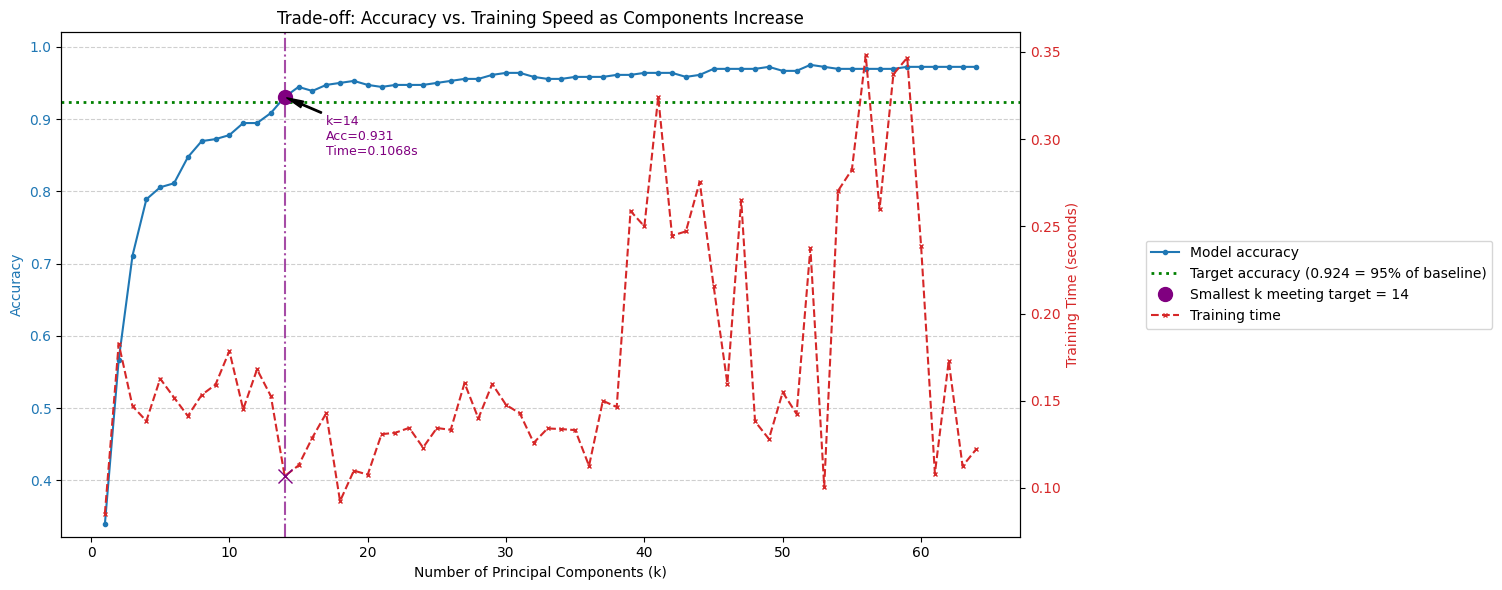

In [9]:
TARGET_ACCURACY = baseline_accuracy * 0.95

indices_met_target = np.where(np.array(accuracy_scores) >= TARGET_ACCURACY)[0]
found_optimal = len(indices_met_target) > 0

if found_optimal:
    k_optimal_index = indices_met_target[0]
    k_optimal_value = list(components_range)[k_optimal_index]
    optimal_time = training_times[k_optimal_index]
    optimal_acc = accuracy_scores[k_optimal_index]
else:
    print(f"Warning: target accuracy of {TARGET_ACCURACY:.3f} was not reached in this sweep.")

fig, ax1 = plt.subplots(figsize=(11, 6))

color_acc = 'tab:blue'
ax1.set_xlabel('Number of Principal Components (k)')
ax1.set_ylabel('Accuracy', color=color_acc)
ax1.plot(list(components_range), accuracy_scores, color=color_acc, marker='o', markersize=3, linestyle='-', label='Model accuracy')
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)
ax1.axhline(y=TARGET_ACCURACY, color='green', linestyle=':', linewidth=2,
            label=f'Target accuracy ({TARGET_ACCURACY:.3f} = 95% of baseline)')
ax1.set_ylim(min(accuracy_scores) * 0.95, 1.02)

ax2 = ax1.twinx()
color_time = 'tab:red'
ax2.set_ylabel('Training Time (seconds)', color=color_time)
ax2.plot(list(components_range), training_times, color=color_time, marker='x', markersize=3, linestyle='--', label='Training time')
ax2.tick_params(axis='y', labelcolor=color_time)

if found_optimal:
    plt.axvline(x=k_optimal_value, color='purple', linestyle='-.', alpha=0.7)
    ax1.plot(k_optimal_value, optimal_acc, 'o', color='purple', markersize=10, label=f'Smallest k meeting target = {k_optimal_value}')
    ax2.plot(k_optimal_value, optimal_time, 'x', color='purple', markersize=10)
    ax1.annotate(f'k={k_optimal_value}\nAcc={optimal_acc:.3f}\nTime={optimal_time:.4f}s',
                 xy=(k_optimal_value, optimal_acc),
                 xytext=(k_optimal_value + 3, optimal_acc - 0.08),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                 fontsize=9, color='purple')

plt.title('Trade-off: Accuracy vs. Training Speed as Components Increase')
fig.tight_layout()
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='center right', bbox_to_anchor=(1.5, 0.5))
plt.savefig('../result/pca_performance.png', bbox_inches='tight')
plt.show()

## STEP 06 - 2D Projection

Compressing to just 2 components is far too aggressive for accuracy, but it's the only count that can be plotted directly.

Variance explained by 2 components: 21.6% (compare to 40 components needed for 95%)


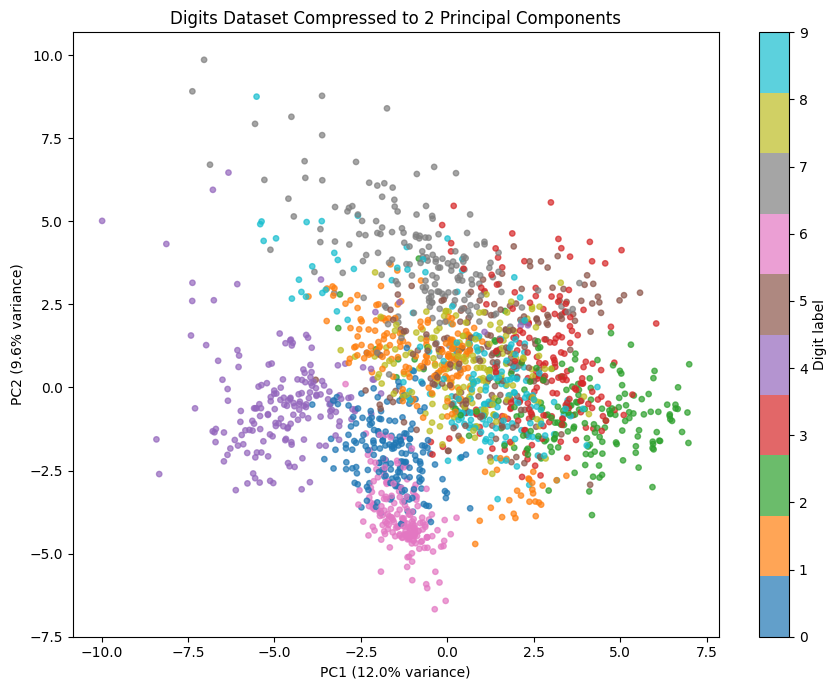

In [10]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"Variance explained by 2 components: {pca_2d.explained_variance_ratio_.sum():.1%} "
      f"(compare to {pca.n_components_} components needed for 95%)")

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter, label='Digit label', ticks=range(10))
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Digits Dataset Compressed to 2 Principal Components')
plt.tight_layout()
plt.savefig('../result/pca_2d_projection.png')
plt.show()

## Conclusion

95%-variance PCA cuts 64 pixels to 40 components for almost no accuracy loss (0.972 -> 0.964); the sweep finds the smallest k within 5% of baseline; even 2 components (21.6% variance) keep the 10 digit classes visibly separated.